/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


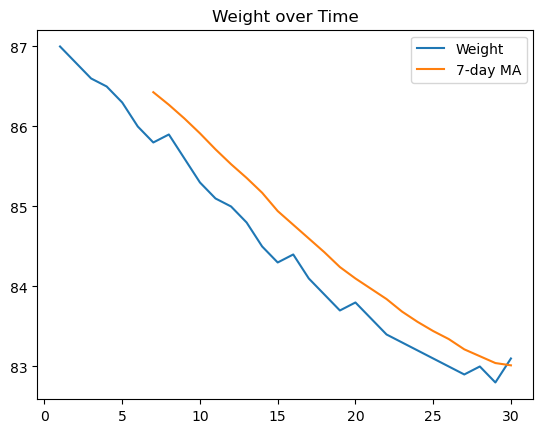

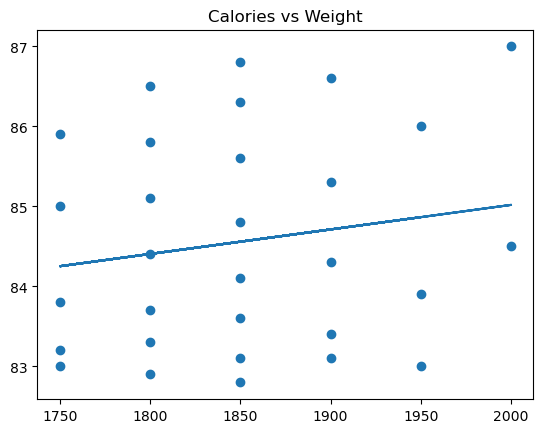

Slope: 0.0030645161290322534
R2: 0.027858171195175307
Predicted weight (1800 kcal): [84.40677419]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# input data
data = [
[1,87.0,2000,60,150,8.5],
[2,86.8,1850,70,140,8.0],
[3,86.6,1900,55,138,8.5],
[4,86.5,1800,0,135,9.0],
[5,86.3,1850,65,140,8.0],
[6,86.0,1950,60,145,8.5],
[7,85.8,1800,50,135,8.0],
[8,85.9,1750,0,132,9.0],
[9,85.6,1850,60,140,8.5],
[10,85.3,1900,70,150,8.0],
[11,85.1,1800,55,135,8.5],
[12,85.0,1750,0,130,9.0],
[13,84.8,1850,65,140,8.5],
[14,84.5,2000,60,150,8.0],
[15,84.3,1900,50,135,8.5],
[16,84.4,1800,0,132,9.0],
[17,84.1,1850,60,140,8.0],
[18,83.9,1950,70,145,8.5],
[19,83.7,1800,55,135,8.0],
[20,83.8,1750,0,130,9.0],
[21,83.6,1850,60,140,8.5],
[22,83.4,1900,65,145,8.0],
[23,83.3,1800,50,135,8.5],
[24,83.2,1750,0,132,9.0],
[25,83.1,1850,60,140,8.0],
[26,83.0,1950,70,150,8.5],
[27,82.9,1800,55,135,8.0],
[28,83.0,1750,0,130,9.0],
[29,82.8,1850,60,140,8.5],
[30,83.1,1900,65,145,8.0]
]

df = pd.DataFrame(data, columns=["day","weight","calories","workout","protein","sleep"])

# moving average
df["MA_7"] = df["weight"].rolling(window=7).mean()

# regression
X = df[["calories"]]
y = df["weight"]

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

# prediction
future_cal = np.array([[1800]])
pred_weight = model.predict(future_cal)

# plots
plt.figure()
plt.plot(df["day"], df["weight"], label="Weight")
plt.plot(df["day"], df["MA_7"], label="7-day MA")
plt.legend()
plt.title("Weight over Time")
plt.show()

plt.figure()
plt.scatter(df["calories"], df["weight"])
plt.plot(df["calories"], model.predict(X))
plt.title("Calories vs Weight")
plt.show()

print("Slope:", slope)
print("R2:", r2)
print("Predicted weight (1800 kcal):", pred_weight)